In [ ]:
!pip install -q kaggle timm
!pip install timm torchvision

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
import torch
import timm
import torchvision.transforms as transforms
from google.colab import files
import os
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import time
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, confusion_matrix, f1_score)

In [ ]:
# Upload file kaggle.json
files.upload()
# Cấp quyền cho file kaggle.json
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Saving kaggle.json to kaggle.json


In [ ]:
# Tải bộ dữ liệu CheXpert (Bản Small - khoảng 11GB)
!kaggle datasets download -d ashery/chexpert

# Giải nén vào thư mục chexpert_data
!unzip -q chexpert.zip -d /content/chexpert_data
print("Giải nén hoàn tất!")

Dataset URL: https://www.kaggle.com/datasets/ashery/chexpert
License(s): CC0-1.0
100% 10.7G/10.7G [02:21<00:00, 81.5MB/s]

Giải nén hoàn tất!


In [ ]:
class CheXpertDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None, policy='u-zeros'):
        """
        csv_file: Đường dẫn tới file train.csv hoặc valid.csv
        root_dir: Thư mục gốc chứa ảnh
        """
        # Đọc file CSV
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

        # 14 nhãn lâm sàng cốt lõi của CheXpert
        self.labels = [
            'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
            'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia',
            'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other',
            'Fracture', 'Support Devices'
        ]

        print(f"Đang xử lý {len(self.df)} mẫu dữ liệu...")

        # Tiền xử lý dữ liệu:
        # 1. Điền giá trị 0 cho các ô trống (NaN)
        self.df[self.labels] = self.df[self.labels].fillna(0)

        # 2. Xử lý nhãn bất định (-1) theo chiến lược đã chọn
        if policy == 'u-zeros':
            self.df[self.labels] = self.df[self.labels].replace(-1, 0)
        elif policy == 'u-ones':
            self.df[self.labels] = self.df[self.labels].replace(-1, 1)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Lấy đường dẫn ảnh từ file CSV (Path)
        img_name = self.df.iloc[idx]['Path']
        clean_path = img_name.replace('CheXpert-v1.0-small/', '')
        img_path = os.path.join(self.root_dir, clean_path)
        # Mở ảnh bằng PIL và chuyển về hệ màu RGB (ConvNeXt yêu cầu đầu vào 3 kênh)
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Lỗi đọc ảnh tại {img_path}: {e}")
            # Trả về ảnh đen nếu lỗi (tránh crash pipeline)
            image = Image.new('RGB', (224, 224))

        if self.transform:
            image = self.transform(image)

        # Trích xuất nhãn thành dạng tensor float 32-bit
        labels = torch.tensor(self.df.iloc[idx][self.labels].values.astype(float), dtype=torch.float32)

        return image, labels


In [ ]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)), # Ép về size chuẩn của ConvNeXt
    transforms.RandomHorizontalFlip(), # Data augmentation cơ bản
    transforms.ToTensor(),
    # Chuẩn hóa theo chuẩn ImageNet
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Đang xử lý 223414 mẫu dữ liệu...
Kích thước tensor của Ảnh (Images shape): torch.Size([32, 3, 224, 224])
Kích thước tensor của Nhãn (Labels shape): torch.Size([32, 14])


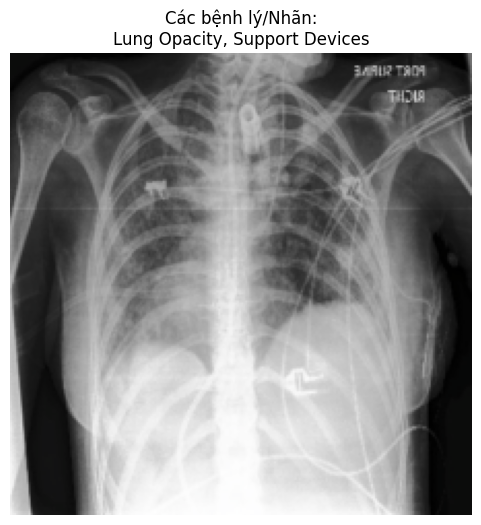

In [ ]:
# Khởi tạo tập dữ liệu
csv_path = '/content/chexpert_data/train.csv'
root_dir = '/content/chexpert_data'
train_dataset = CheXpertDataset(
    csv_file=csv_path,
    root_dir=root_dir,
    transform=transform_train,
    policy='u-zeros' # Ép các nhãn -1 (bất định) thành 0 (âm tính)
)

# Khởi tạo Dataloader để băm dữ liệu thành các batch (lô)
train_loader = DataLoader(
    train_dataset,
    batch_size=32, # Nạp 32 ảnh mỗi lần để tránh tràn RAM
    shuffle=True,  # Xáo trộn dữ liệu để mô hình học tổng quát hơn
    num_workers=2  # Tận dụng luồng CPU của Colab để load ảnh nhanh hơn
)

# 2. KIỂM TRA BATCH ĐẦU TIÊN
# Rút thử 1 batch ra để kiểm tra
images, labels = next(iter(train_loader))

print(f"Kích thước tensor của Ảnh (Images shape): {images.shape}")
print(f"Kích thước tensor của Nhãn (Labels shape): {labels.shape}")

# Kích thước kỳ vọng phải là:
# Ảnh: [32, 3, 224, 224] (32 ảnh, 3 kênh màu RGB, kích thước 224x224)
# Nhãn: [32, 14] (32 ảnh, mỗi ảnh có 14 nhãn lâm sàng)

# 3. TRỰC QUAN HÓA THỬ 1 TẤM ẢNH ĐỂ XÁC NHẬN
def imshow(inp, title=None):
    """Hàm giải chuẩn hóa (un-normalize) để hiển thị ảnh X-quang"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1) # Giới hạn lại giá trị pixel trong khoảng [0, 1]
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.pause(0.001)

# Lấy ảnh đầu tiên trong batch và các nhãn dương tính của nó
first_image = images[0]
first_label_vector = labels[0]

# Lọc ra tên các bệnh lý có nhãn là 1.0
positive_labels = [train_dataset.labels[i] for i, val in enumerate(first_label_vector) if val == 1.0]
title = "Các bệnh lý/Nhãn:\n" + ", ".join(positive_labels) if positive_labels else "No Finding (Bình thường)"

plt.figure(figsize=(6, 6))
imshow(first_image, title=title)
plt.show()

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng thiết bị: {device}")
model = timm.create_model('convnextv2_tiny', pretrained=True, num_classes=14)

# Đẩy mô hình lên GPU
model = model.to(device)

print("Đã tải xong kiến trúc ConvNeXt V2 và cấu hình lại Classifier Head!")

Đang sử dụng thiết bị: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

Đã tải xong kiến trúc ConvNeXt V2 và cấu hình lại Classifier Head!


In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scaler = torch.cuda.amp.GradScaler()
print("Đã thiết lập xong Hàm mất mát và Bộ tối ưu hóa.")

Đã thiết lập xong Hàm mất mát và Bộ tối ưu hóa.


/tmp/ipykernel_413/441532052.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
epochs = 1

print(f"🚀 BẮT ĐẦU HUẤN LUYỆN: {epochs} EPOCH")

# Vòng lặp lớn cho mỗi Epoch
for epoch in range(epochs):
    model.train() # Đặt mô hình ở chế độ huấn luyện (bật Dropout, BatchNorm...)
    running_loss = 0.0

    # Tạo thanh tiến trình cho batch
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)

    for batch_idx, (images, labels) in enumerate(progress_bar):
        # 1. Đẩy dữ liệu lên GPU
        images = images.to(device)
        labels = labels.to(device)

        # 2. Xóa các gradient cũ từ bước trước
        optimizer.zero_grad()

        # 3. Kỹ thuật Mixed Precision (Tối ưu RAM Colab)
        with torch.cuda.amp.autocast():
            # Truyền ảnh qua mô hình (Forward pass)
            outputs = model(images)
            # Tính toán sai số (Loss)
            loss = criterion(outputs, labels)

        # 4. Lan truyền ngược (Backward pass) với Scaler
        scaler.scale(loss).backward()

        # 5. Cập nhật trọng số (Update weights)
        scaler.step(optimizer)
        scaler.update()

        # Cập nhật thông số lên thanh tiến trình để theo dõi realtime
        running_loss += loss.item()
        progress_bar.set_postfix({'Loss': f"{loss.item():.4f}"})

    # Tính Loss trung bình của cả Epoch
    epoch_loss = running_loss / len(train_loader)
    print(f"✅ Kết thúc Epoch {epoch+1} | Loss trung bình: {epoch_loss:.4f}\n")

# LƯU LẠI THÀNH QUẢ SAU KHI TRAIN XONG
save_path = '/content/convnextv2_chexpert_weights.pth'
torch.save(model.state_dict(), save_path)
print(f"💾 Đã lưu trọng số mô hình tại: {save_path}")

🚀 BẮT ĐẦU HUẤN LUYỆN: 1 EPOCH


Epoch 1/1:   0%|          | 0/6982 [00:00<?, ?it/s]/tmp/ipykernel_413/118591115.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/1: 100%|██████████| 6982/6982 [39:18<00:00,  2.96it/s, Loss=0.2157]


✅ Kết thúc Epoch 1 | Loss trung bình: 0.2857

💾 Đã lưu trọng số mô hình tại: /content/convnextv2_chexpert_weights.pth


In [ ]:
valid_csv_path = '/content/chexpert_data/valid.csv'

valid_dataset = CheXpertDataset(
    csv_file=valid_csv_path,
    root_dir=root_dir, # Kế thừa root_dir từ bước trước
    transform=transform_val, # Dùng transform_val (không có Augmentation)
    policy='u-zeros'
)

# Tập Valid không cần shuffle (xáo trộn) để dễ đối chiếu kết quả
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=2)

# 2. RÚT TRÍCH DỰ ĐOÁN (PREDICTIONS)
all_preds = []
all_labels = []

# Đặt mô hình ở chế độ đánh giá (Tắt Dropout và cố định BatchNorm)
model.eval()
print("⏳ Đang tiến hành chẩn đoán trên tập Validation...")

# Tắt tính toán Gradient để tiết kiệm tối đa VRAM
with torch.no_grad():
    for images, labels in tqdm(valid_loader, desc="Đánh giá"):
        images = images.to(device)
        outputs = model(images)

        # Vì hàm mất mát là BCEWithLogits, đầu ra là số thực thô (Logits).
        # Ta phải dùng hàm Sigmoid để ép nó về dải xác suất [0, 1].
        probs = torch.sigmoid(outputs)

        # Chuyển dữ liệu về CPU để thư viện sklearn có thể tính toán
        all_preds.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

# Gộp danh sách các batch thành 2 ma trận lớn
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

print("\n📊 BÁO CÁO HIỆU NĂNG LÂM SÀNG TRÊN 14 NHÃN (EVALUATION METRICS):")
print("-" * 110)

results = []

for i, label_name in enumerate(valid_dataset.labels):
    y_t = all_labels[:, i]
    y_p = all_preds[:, i]

    # Xử lý ngoại lệ (ValueError) như bạn đã làm:
    # Tránh lỗi khi tập Valid không có bệnh nhân nào mắc bệnh này (VD: Fracture)
    if len(np.unique(y_t)) < 2:
        print(f"🔹 {label_name:<28} | Không thể tính (Thiếu ca dương tính trong tập test)")
        results.append({
            'Bệnh lý': label_name, 'AUROC': np.nan, 'AUPRC': np.nan,
            'Ngưỡng (Threshold)': np.nan, 'Độ nhạy': np.nan,
            'Độ đặc hiệu': np.nan, 'F1-Score': np.nan
        })
        continue

    # Tính các độ đo độc lập với ngưỡng
    score_auroc = roc_auc_score(y_t, y_p)
    score_auprc = average_precision_score(y_t, y_p)

    # Tự động tìm Ngưỡng chẩn đoán tối ưu (Youden's J Statistic)
    fpr, tpr, thresholds = roc_curve(y_t, y_p)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]

    # Ép xác suất thành dự đoán 0/1 dựa trên ngưỡng vừa tìm được
    y_pred_bin = (y_p >= optimal_threshold).astype(int)

    # Tính các độ đo lâm sàng
    tn, fp, fn, tp = confusion_matrix(y_t, y_pred_bin).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_t, y_pred_bin)

    # In ra màn hình console để theo dõi nhanh
    print(f"🔹 {label_name:<28} | AUROC: {score_auroc:.4f} | AUPRC: {score_auprc:.4f} | Nhạy: {sensitivity:.4f} | Đặc hiệu: {specificity:.4f}")

    # Lưu vào danh sách để tạo bảng DataFrame
    results.append({
        'Bệnh lý': label_name,
        'AUROC': round(score_auroc, 4),
        'AUPRC': round(score_auprc, 4),
        'Ngưỡng (Threshold)': round(optimal_threshold, 4),
        'Độ nhạy': round(sensitivity, 4),
        'Độ đặc hiệu': round(specificity, 4),
        'F1-Score': round(f1, 4)
    })

print("-" * 110)

# ==========================================
# 4. TỔNG HỢP VÀ LƯU KẾT QUẢ ĐỂ BÁO CÁO
# ==========================================
df_results = pd.DataFrame(results)

# Tính dòng Trung bình (Macro Average) bỏ qua các nhãn bị NaN
macro_avg = df_results.mean(numeric_only=True).round(4)
macro_avg['Bệnh lý'] = 'TRUNG BÌNH (MACRO AVG)'

# Chèn dòng Macro vào cuối bảng
df_results = pd.concat([df_results, pd.DataFrame([macro_avg])], ignore_index=True)

# Hiển thị bảng đẹp mắt trên Colab
display(df_results)

# Xuất ra file Excel/CSV để dán vào Khóa luận hoặc vẽ biểu đồ
df_results.to_csv('/content/chexpert_evaluation_metrics.csv', index=False)
print("✅ Đã lưu kết quả chi tiết tại: /content/chexpert_evaluation_metrics.csv")

Đang xử lý 234 mẫu dữ liệu...
⏳ Đang tiến hành chẩn đoán trên tập Validation...


Đánh giá: 100%|██████████| 8/8 [00:06<00:00,  1.18it/s]



📊 BÁO CÁO HIỆU NĂNG LÂM SÀNG TRÊN 14 NHÃN (EVALUATION METRICS):
--------------------------------------------------------------------------------------------------------------
🔹 No Finding                   | AUROC: 0.8691 | AUPRC: 0.4520 | Nhạy: 0.9474 | Đặc hiệu: 0.7245
🔹 Enlarged Cardiomediastinum   | AUROC: 0.5306 | AUPRC: 0.5265 | Nhạy: 0.3853 | Đặc hiệu: 0.7840
🔹 Cardiomegaly                 | AUROC: 0.7919 | AUPRC: 0.6592 | Nhạy: 0.7059 | Đặc hiệu: 0.8012
🔹 Lung Opacity                 | AUROC: 0.9109 | AUPRC: 0.9267 | Nhạy: 0.8810 | Đặc hiệu: 0.8241
🔹 Lung Lesion                  | AUROC: 0.5708 | AUPRC: 0.0099 | Nhạy: 1.0000 | Đặc hiệu: 0.5708
🔹 Edema                        | AUROC: 0.9064 | AUPRC: 0.7465 | Nhạy: 0.8444 | Đặc hiệu: 0.8466
🔹 Consolidation                | AUROC: 0.9126 | AUPRC: 0.6082 | Nhạy: 0.9697 | Đặc hiệu: 0.8109
🔹 Pneumonia                    | AUROC: 0.7517 | AUPRC: 0.1286 | Nhạy: 0.6250 | Đặc hiệu: 0.8850
🔹 Atelectasis                  | AUROC: 0.7856 |

,Bệnh lý,AUROC,AUPRC,Ngưỡng (Threshold),Độ nhạy,Độ đặc hiệu,F1-Score
0,No Finding,0.8691,0.4520,0.1221,0.9474,0.7245,0.5625
1,Enlarged Cardiomediastinum,0.5306,0.5265,0.0521,0.3853,0.7840,0.4719
2,Cardiomegaly,0.7919,0.6592,0.0555,0.7059,0.8012,0.6443
3,Lung Opacity,0.9109,0.9267,0.3040,0.8810,0.8241,0.8672
4,Lung Lesion,0.5708,0.0099,0.0247,1.0000,0.5708,0.0196
5,Edema,0.9064,0.7465,0.1722,0.8444,0.8466,0.6786
6,Consolidation,0.9126,0.6082,0.0699,0.9697,0.8109,0.6214
7,Pneumonia,0.7517,0.1286,0.0377,0.6250,0.8850,0.2564
8,Atelectasis,0.7856,0.6003,0.1448,0.8125,0.6623,0.6599
9,Pneumothorax,0.8031,0.1823,0.0620,0.7500,0.7876,0.1935


✅ Đã lưu kết quả chi tiết tại: /content/chexpert_evaluation_metrics.csv


In [ ]:
import os
import torch
import numpy as np
from tqdm import tqdm

# 1. "CHẶT BỎ" LỚP PHÂN LOẠI CUỐI CÙNG
# Lệnh reset_classifier(0) của thư viện timm sẽ gỡ bỏ lớp fully connected (fc) ở cuối.
# Giờ đây, model(x) sẽ không trả về 14 nhãn nữa, mà trả về vector đặc trưng gốc.
model.reset_classifier(0)
model.eval()

print("✂️ Đã gỡ bỏ lớp phân loại! Mô hình hiện đóng vai trò là Bộ Trích Xuất (Feature Extractor).")

# 2. ĐỊNH NGHĨA HÀM TRÍCH XUẤT CHUNG
def extract_embeddings(dataloader, desc="Trích xuất"):
    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=desc):
            images = images.to(device)

            # Đẩy ảnh qua phần thân của ConvNeXt V2
            with torch.amp.autocast('cuda'): # Vẫn dùng Mixed Precision để chống tràn RAM
                embeddings = model(images)

            # Đưa vector từ GPU về CPU và lưu lại
            all_embeddings.append(embeddings.cpu().numpy())
            all_labels.append(labels.numpy())

    # Xếp chồng các batch lại thành ma trận lớn
    return np.vstack(all_embeddings), np.vstack(all_labels)

# 3. TIẾN HÀNH TRÍCH XUẤT
# Lời khuyên: Để tiết kiệm thời gian chờ đợi trên Colab hiện tại,
# chúng ta sẽ trích xuất trên tập Validation trước để xây dựng khung PCBM.
# (Sau khi code chuẩn, bạn có thể tự chạy trích xuất trên tập Train sau).

print("\n⏳ Đang trích xuất vector đặc trưng từ tập Validation...")
val_embeddings, val_labels = extract_embeddings(valid_loader, "Valid Embeddings")

print("\n✅ HOÀN TẤT TRÍCH XUẤT!")
print(f"Kích thước ma trận Đặc trưng (X): {val_embeddings.shape}")
print(f"Kích thước ma trận Khái niệm (Y): {val_labels.shape}")
# Kỳ vọng X sẽ có dạng [Số lượng ảnh, 768] và Y có dạng [Số lượng ảnh, 14]

# 4. LƯU "KHO TÀNG" NÀY VÀO Ổ CỨNG
save_dir = '/content/chexpert_data/'
np.save(os.path.join(save_dir, 'val_embeddings.npy'), val_embeddings)
np.save(os.path.join(save_dir, 'val_labels.npy'), val_labels)

print(f"💾 Đã lưu 2 file 'val_embeddings.npy' và 'val_labels.npy' tại {save_dir}")

✂️ Đã gỡ bỏ lớp phân loại! Mô hình hiện đóng vai trò là Bộ Trích Xuất (Feature Extractor).

⏳ Đang trích xuất vector đặc trưng từ tập Validation...


Valid Embeddings: 100%|██████████| 8/8 [00:10<00:00,  1.37s/it]


✅ HOÀN TẤT TRÍCH XUẤT!
Kích thước ma trận Đặc trưng (X): (234, 768)
Kích thước ma trận Khái niệm (Y): (234, 14)
💾 Đã lưu 2 file 'val_embeddings.npy' và 'val_labels.npy' tại /content/chexpert_data/


In [ ]:
import os
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import joblib # Thư viện dùng để lưu mô hình Machine Learning truyền thống

# 1. LOAD LẠI DỮ LIỆU ĐÃ TRÍCH XUẤT
save_dir = '/content/chexpert_data/'
print("Đang nạp dữ liệu vector từ ổ cứng...")
X = np.load(os.path.join(save_dir, 'val_embeddings.npy'))
Y = np.load(os.path.join(save_dir, 'val_labels.npy'))

# Danh sách 14 nhãn lâm sàng
labels = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
    'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia',
    'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other',
    'Fracture', 'Support Devices'
]

# 2. ĐÀO TẠO 14 THẨM ĐỊNH VIÊN (CONCEPT MODELS)
concept_bank = {}

print("\n🚀 BẮT ĐẦU ĐÀO TẠO KHO KHÁI NIỆM (CONCEPT BANK):")
print("-" * 65)

for i, concept_name in enumerate(labels):
    # Trích xuất nhãn của khái niệm thứ i (Ép kiểu về số nguyên Int để chạy Logistic)
    y_concept = Y[:, i].astype(int)

    # Kiểm tra xem khái niệm này có đủ cả mẫu Đúng (1) và Sai (0) không
    # (Nhớ lại lỗi Fracture toàn số 0 ở bước trước)
    if len(np.unique(y_concept)) > 1:

        # Khởi tạo Thẩm định viên (Logistic Regression)
        # class_weight='balanced' giúp xử lý sự mất cân bằng dữ liệu cực kỳ tốt
        clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

        # Cho Thẩm định viên học cách ánh xạ từ Vector (X) sang Khái niệm (y)
        clf.fit(X, y_concept)

        # Tự đánh giá lại năng lực học của Thẩm định viên (Tính AUROC)
        # Lấy cột xác suất thứ 1 (Xác suất dương tính)
        preds = clf.predict_proba(X)[:, 1]
        auc = roc_auc_score(y_concept, preds)

        # Lưu Thẩm định viên vào Kho chứa
        concept_bank[concept_name] = clf
        print(f"✅ Thẩm định viên [{concept_name:<28}] - Học thành công! (AUROC: {auc:.4f})")
    else:
        print(f"❌ Thẩm định viên [{concept_name:<28}] - Bỏ qua (Dữ liệu thiếu đa dạng)")

print("-" * 65)

# 3. LƯU KHO KHÁI NIỆM VÀO Ổ CỨNG
bank_path = os.path.join(save_dir, 'chexpert_concept_bank.pkl')
joblib.dump(concept_bank, bank_path)
print(f"💾 Đã lưu toàn bộ Kho Khái Niệm tại: {bank_path}")

Đang nạp dữ liệu vector từ ổ cứng...

🚀 BẮT ĐẦU ĐÀO TẠO KHO KHÁI NIỆM (CONCEPT BANK):
-----------------------------------------------------------------
✅ Thẩm định viên [No Finding                  ] - Học thành công! (AUROC: 1.0000)
✅ Thẩm định viên [Enlarged Cardiomediastinum  ] - Học thành công! (AUROC: 1.0000)
✅ Thẩm định viên [Cardiomegaly                ] - Học thành công! (AUROC: 1.0000)
✅ Thẩm định viên [Lung Opacity                ] - Học thành công! (AUROC: 1.0000)
✅ Thẩm định viên [Lung Lesion                 ] - Học thành công! (AUROC: 1.0000)
✅ Thẩm định viên [Edema                       ] - Học thành công! (AUROC: 1.0000)
✅ Thẩm định viên [Consolidation               ] - Học thành công! (AUROC: 1.0000)
✅ Thẩm định viên [Pneumonia                   ] - Học thành công! (AUROC: 1.0000)
✅ Thẩm định viên [Atelectasis                 ] - Học thành công! (AUROC: 0.9997)
✅ Thẩm định viên [Pneumothorax                ] - Học thành công! (AUROC: 1.0000)
✅ Thẩm định viên [Pleural Ef

Đang dịch Vector 768 chiều thành Không gian Khái niệm...
🚀 Đang huấn luyện Mô hình PCBM cho bệnh Viêm phổi...


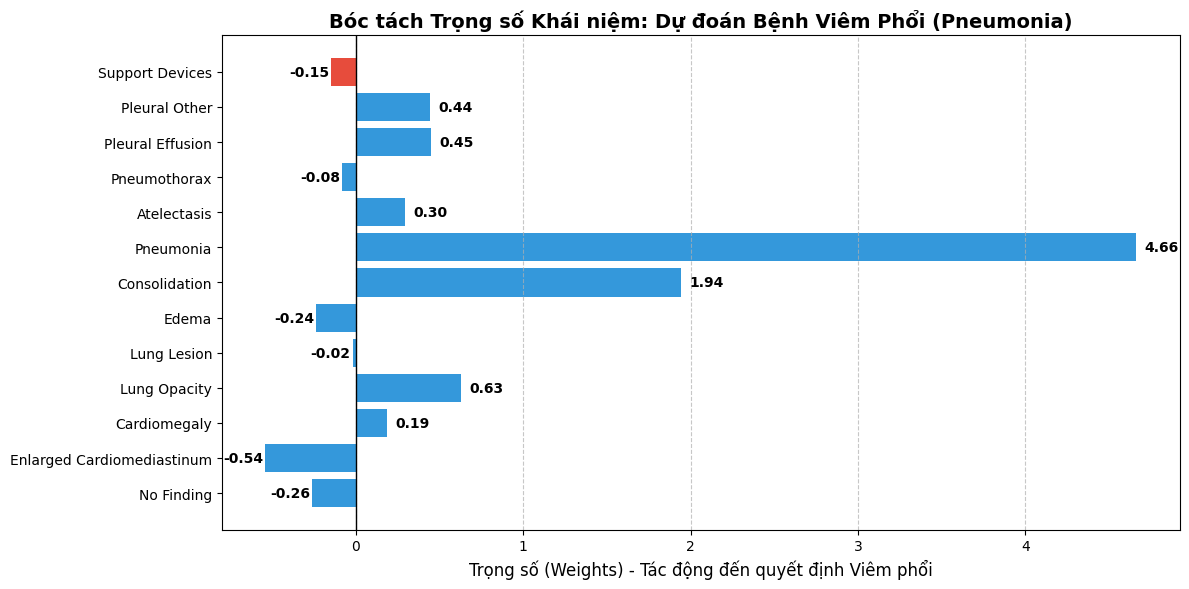

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# 1. TẠO MA TRẬN KHÁI NIỆM (CONCEPT MATRIX - C)
# Thay vì dùng Vector hộp đen 768 chiều, ta dùng điểm số của 13 Thẩm định viên
print("Đang dịch Vector 768 chiều thành Không gian Khái niệm...")
concept_names = list(concept_bank.keys())
C_matrix = []

for name in concept_names:
    clf = concept_bank[name]
    # Lấy xác suất dương tính của từng khái niệm
    concept_probs = clf.predict_proba(X)[:, 1]
    C_matrix.append(concept_probs)

# Ma trận C mới sẽ có kích thước [Số lượng ảnh, 13 khái niệm]
C_matrix = np.column_stack(C_matrix)

# 2. CHUẨN BỊ NHÃN MỤC TIÊU: PNEUMONIA (VIÊM PHỔI)
# Tìm vị trí cột của Pneumonia trong tập nhãn gốc Y
pneumonia_idx = labels.index('Pneumonia')
y_target = Y[:, pneumonia_idx].astype(int)

# 3. ĐÀO TẠO MÔ HÌNH PHÂN LOẠI TUYẾN TÍNH CUỐI CÙNG
print("🚀 Đang huấn luyện Mô hình PCBM cho bệnh Viêm phổi...")
# Lại dùng class_weight='balanced' để chống mất cân bằng
final_clf = LogisticRegression(max_iter=1000, class_weight='balanced')
final_clf.fit(C_matrix, y_target)

# 4. TRÍCH XUẤT TRỌNG SỐ (WEIGHTS) VÀ TRỰC QUAN HÓA
weights = final_clf.coef_[0]

# Vẽ biểu đồ Bar Chart cực kỳ chuyên nghiệp cho Slide báo cáo
plt.figure(figsize=(12, 6))

# Định dạng màu sắc: Nhãn bệnh lý màu xanh, Support Devices màu đỏ gạch (để nhấn mạnh)
colors = ['#e74c3c' if name == 'Support Devices' else '#3498db' for name in concept_names]

# Vẽ biểu đồ
bars = plt.barh(concept_names, weights, color=colors)
plt.axvline(x=0, color='black', linewidth=1)
plt.xlabel('Trọng số (Weights) - Tác động đến quyết định Viêm phổi', fontsize=12)
plt.title('Bóc tách Trọng số Khái niệm: Dự đoán Bệnh Viêm Phổi (Pneumonia)', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Gắn con số cụ thể lên từng thanh
for bar in bars:
    width = bar.get_width()
    label_x_pos = width + 0.05 if width > 0 else width - 0.25
    plt.text(label_x_pos, bar.get_y() + bar.get_height()/2, f'{width:.2f}',
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

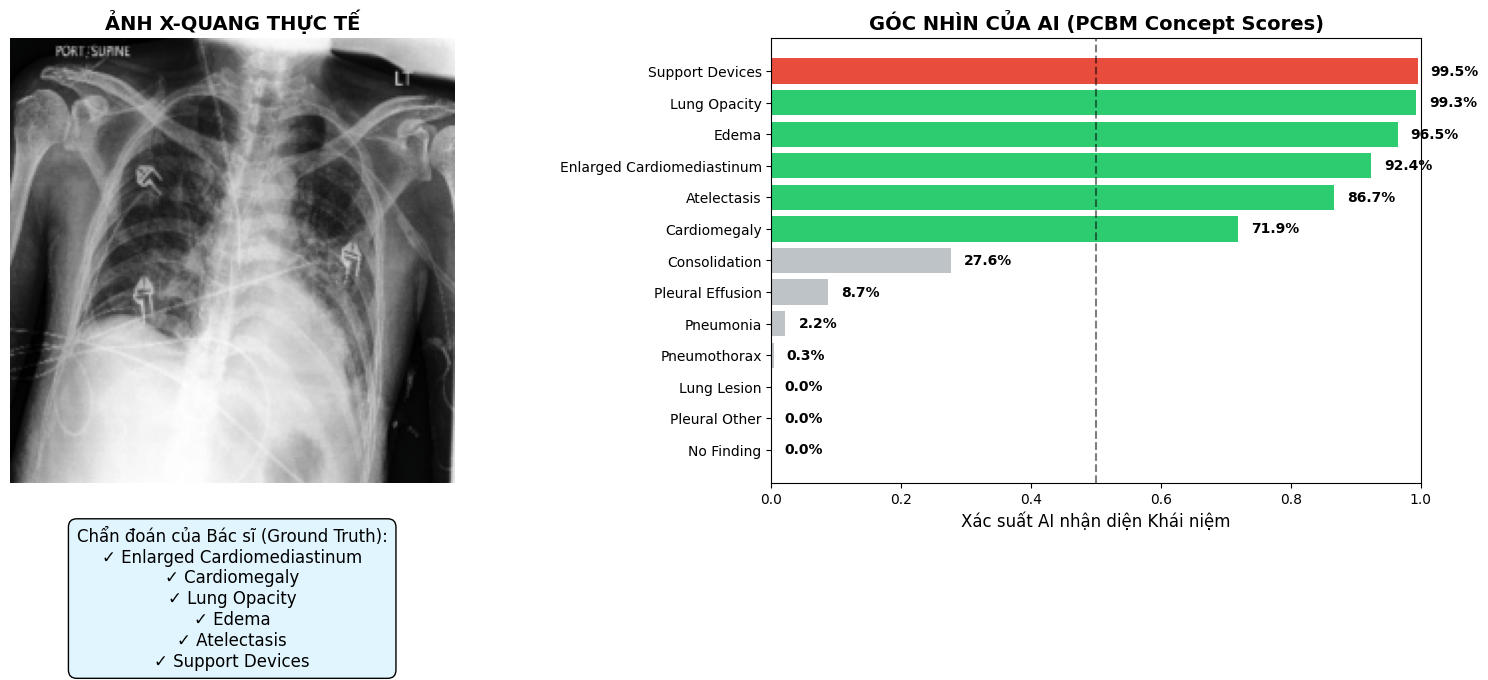

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import random

# 1. RÚT NGẪU NHIÊN 1 TẤM ẢNH TỪ TẬP VALIDATION
# Bạn có thể thay đổi số seed hoặc bỏ đi để mỗi lần chạy ra một ảnh khác nhau
random_idx = random.randint(0, len(valid_dataset) - 1)
image, true_labels = valid_dataset[random_idx]

# 2. GÓC NHÌN CỦA BÁC SĨ (GROUND TRUTH)
# Lọc ra các bệnh lý thực sự tồn tại trên ảnh này (Nhãn == 1.0)
doctor_diagnosis = [valid_dataset.labels[i] for i, val in enumerate(true_labels) if val == 1.0]
if not doctor_diagnosis:
    doctor_diagnosis = ["No Finding (Khỏe mạnh)"]

# 3. GÓC NHÌN CỦA AI (PCBM CONCEPT SCORES)
model.eval()
with torch.no_grad():
    with torch.amp.autocast('cuda'):
        # Thêm chiều batch (1, 3, 224, 224) và đẩy lên GPU
        img_tensor = image.unsqueeze(0).to(device)
        # Rút trích vector 768 chiều
        embedding = model(img_tensor).cpu().numpy()

# Chạy vector qua 13 Thẩm định viên để lấy điểm số phần trăm
ai_concept_scores = {}
for concept_name, clf in concept_bank.items():
    # Lấy xác suất mô hình cho là có khái niệm này
    prob = clf.predict_proba(embedding)[0, 1]
    ai_concept_scores[concept_name] = prob

# Sắp xếp điểm số từ cao xuống thấp để vẽ biểu đồ cho đẹp
sorted_concepts = sorted(ai_concept_scores.items(), key=lambda x: x[1], reverse=False)
concept_names = [x[0] for x in sorted_concepts]
concept_probs = [x[1] for x in sorted_concepts]

# 4. VẼ BẢNG ĐIỀU KHIỂN ĐỐI CHIẾU (DASHBOARD)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- Cột trái: Ảnh X-quang và Chẩn đoán của Bác sĩ ---
# Giải chuẩn hóa ảnh để hiển thị
img_display = image.numpy().transpose((1, 2, 0))
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_display = std * img_display + mean
img_display = np.clip(img_display, 0, 1)

ax1.imshow(img_display)
ax1.axis('off')
ax1.set_title("ẢNH X-QUANG THỰC TẾ", fontsize=14, fontweight='bold')

# Ghi chú chẩn đoán của Bác sĩ dưới gầm ảnh
doctor_text = "Chẩn đoán của Bác sĩ (Ground Truth):\n" + "\n".join([f"✓ {d}" for d in doctor_diagnosis])
ax1.text(0.5, -0.1, doctor_text, transform=ax1.transAxes, ha='center', va='top',
         fontsize=12, bbox=dict(facecolor='#e1f5fe', edgecolor='black', boxstyle='round,pad=0.5'))

# --- Cột phải: Góc nhìn của máy (Concept Scores) ---
colors = ['#e74c3c' if name == 'Support Devices' else '#2ecc71' if prob > 0.5 else '#bdc3c7'
          for name, prob in zip(concept_names, concept_probs)]

bars = ax2.barh(concept_names, concept_probs, color=colors)
ax2.set_xlim(0, 1.0)
ax2.axvline(x=0.5, color='black', linestyle='--', alpha=0.5) # Đường ranh giới 50%
ax2.set_xlabel('Xác suất AI nhận diện Khái niệm', fontsize=12)
ax2.set_title("GÓC NHÌN CỦA AI (PCBM Concept Scores)", fontsize=14, fontweight='bold')

# Gắn số % lên thanh
for bar in bars:
    width = bar.get_width()
    ax2.text(width + 0.02, bar.get_y() + bar.get_height()/2, f'{width*100:.1f}%',
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
!pip install  scikit-image